In [148]:
print("test")

test


In [149]:
#Charger dataset
from datasets import load_dataset
import numpy as np

In [150]:
ds = load_dataset("imdb") #the datasets library recognizes "imdb" as a predefined dataset.

In [151]:
ds
#Le dataset est composé de 3 parties : train et test, que nous utiliserons, et unsupervised que nous n’utiliserons pas.
#Chaque partie contient des exemples de critiques de films avec leur sentiment associé (positif ou négatif).

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [152]:
train_df = ds['train'].to_pandas()
#to_pandas() pour convertir en Pandas DataFrame :
# facile à afficher, filtrer, analyser
# compatible avec beaucoup de libs (matplotlib, sklearn, etc.)

In [153]:
# train_df.head()
train_df.sample(5)

,text,label
14118,Goebbels motivation in backing down was not ex...,1
16197,Being a person who does not usually enjoy boxi...,1
3253,"Once again, like Charlie's Angels, Inspector G...",0
12475,"This is the worst brain damaged, ultra cheap, ...",0
5040,I can't even believe that this show lasted as ...,0


In [154]:
#vérifier si le dataset est équilibré:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [155]:
# train_df['sentiment'] = train_df['label'].map({0: 'negatif', 1: 'positif'})
train_df['sentiment'] = np.where(train_df['label']==1, "positif","negatif")

In [156]:
train_df
#train_df['sentiment'] same as train_df.sentiment

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negatif
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negatif
2,If only to avoid making this type of film in t...,0,negatif
3,This film was probably inspired by Godard's Ma...,0,negatif
4,"Oh, brother...after hearing about this ridicul...",0,negatif
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positif
24996,I love this movie like no other. Another time ...,1,positif
24997,This film and it's sequel Barry Mckenzie holds...,1,positif
24998,'The Adventures Of Barry McKenzie' started lif...,1,positif


In [157]:
train_df.sentiment.value_counts()

sentiment
negatif    12500
positif    12500
Name: count, dtype: int64

<Axes: >

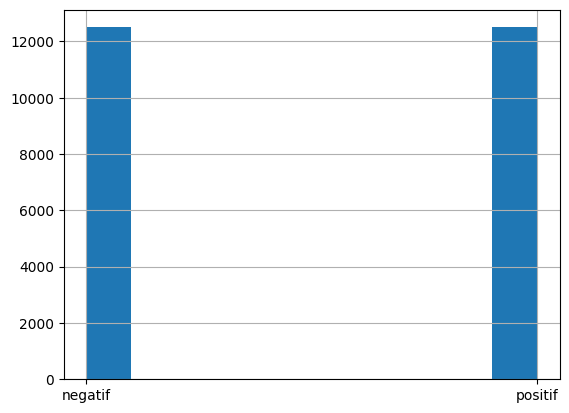

In [158]:
train_df.sentiment.hist()

In [159]:
from sklearn.model_selection import train_test_split

In [160]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
    #0.2 cad 20% examples rest gold_examples
)

In [161]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [162]:
columns = ["text", "sentiment"]
gold_examples = (
                 gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient="records")#Très pratique pour envoyer à un LLM/API.
                ) 

In [163]:
import json

In [164]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positif'}

## Elaborer les prompts

#### Prompt 1: Zero-shot

In [165]:
user_prompt_template = """```{movie_review}```"""

In [166]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [167]:
zero_shot_prompt = [
    {"role":"system", "content": zero_shot_system_message}
]

In [168]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [169]:
#pour le few shot prompt nous aurons besoin de quelques exemples variés, cad des critiques positives et négatives
#on va diviser les examples on deux (positif et negatif) et prendre 4 exemples de chaque pour les inclure in random order dans le prompt few shot
examples_df.shape

(20000, 3)

In [170]:
positif_reviews_df = (
        examples_df[examples_df.sentiment=="positif"][columns]
        .sample(4)
)

In [171]:
negatif_reviews_df = (
                examples_df[examples_df.sentiment=="negatif"][columns]
                .sample(4))

In [172]:
negatif_reviews_df

,text,sentiment
2245,I bought this DVD for £1 and now i realise why...,negatif
2353,"There are movies like ""Plan 9"" that are so bad...",negatif
2584,"In an interview, David Duchovny said he hasn't...",negatif
1782,Bad Movie - saw it at the TIFF and the movie g...,negatif


In [173]:
positif_reviews_df.shape, negatif_reviews_df.shape

((4, 2), (4, 2))

In [174]:
import pandas as pd

In [175]:
ex = pd.concat([positif_reviews_df, negatif_reviews_df])

In [176]:
ex
#problème : les exemples positifs sont regroupés et les négatifs aussi, il faut les mélanger

,text,sentiment
16121,With the sun shining brilliantly on a quiet Su...,positif
23418,"I knew about but had never seen Grey Gardens, ...",positif
14584,I approached this film with low expectations b...,positif
23771,The dazzling seventeen-minute dance sequence o...,positif
2245,I bought this DVD for £1 and now i realise why...,negatif
2353,"There are movies like ""Plan 9"" that are so bad...",negatif
2584,"In an interview, David Duchovny said he hasn't...",negatif
1782,Bad Movie - saw it at the TIFF and the movie g...,negatif


In [177]:
examples = examples_df.sample(4*2, replace=False).to_json(orient='records')

In [178]:
json.loads(examples)

[{'text': "Wow! So much fun! Probably a bit much for normal American kids, and really it's a stretch to call this a kid's film, this movie reminded me a quite a bit of Time Bandits - very Terry Gilliam all the way through. While the overall narrative is pretty much straight forward, Miike still throws in A LOT of surreal and Bunuel-esquire moments. The whole first act violently juxtaposes from scene to scene the normal family life of the main kid/hero, with the spirit world and the evil than is ensuing therein. And while the ending does have a bit of an ambiguous aspect that are common of Miike's work, the layers of meaning and metaphor, particularly the anti-war / anti-revenge message of human folly, is pretty damn poignant. As manic and imaginatively fun as other great Miike films, only instead of over the top torture and gore, he gives us an endless amount of monsters and yokai from Japanese folk-lore creatively conceived via CG and puppetry wrapped into an imaginative multi-faceted

In [192]:
def create_examples(dataset, n=4):
    positive_reviews_df = (
                dataset[dataset['sentiment'] == 'positif'][columns]
                .sample(n)
                )
    negative_reviews_df = (
                dataset[dataset['sentiment'] == 'negatif'][columns]
                .sample(n)
                )

    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])
    examples = examples_df.sample(2*n, replace=False)
    
    return examples.to_json(orient='records')

In [193]:
examples_df.shape

(20000, 3)

In [195]:
examples = create_examples(examples_df, n=6)

In [196]:
json.loads(examples)[0]

{'text': "I am not one of those people who just go online after I see a movie and decide to call it the worst movie ever made. If you doubt me, please look at my other reviews. However, for the first time ever, I have seen a movie so horrible that I wanted to write about how bad it was before it was even over.<br /><br />I LOVE bad movies. To me, Ed Wood is a genius, I thought Bloody Murder, Jeepers Creepers and most horrible horror movies were good. However, there is not a single good thing I can say about this film.<br /><br />The plot is basically non existent. If someone reading my review wastes their money to see it, they can discern for themselves what the plot might be, but I advise you that a nickel would be worth more than watching this movie.<br /><br />The special effects are bad.<br /><br />The acting is bad.<br /><br />The two leads are attractive, but that's all there is.<br /><br />I am not the type to spoil a movie for anyone, but I INVITE anyone to email me at foxbarki

In [198]:
#few shot propt fct:
def create_few_shot_prompt(system_message, examples, user_prompt_template):
    few_shot_prompt = [
        {"role": "system", "content": system_message},
    ]

    for examples in examples : 
        review = examples["text"]
        sentiment = examples["sentiment"]
        few_shot_prompt.append({"role": "user", "content": user_prompt_template.format(movie_review=review)})
        few_shot_prompt.append({"role": "assistant", "content": f"{sentiment}"}) 
        #la format f"{}" c'est juste pour spécifier que c est du text

    return few_shot_prompt

In [ ]:
few_shot_prompt = create_few_shot_prompt(few_shot_system_message, json.loads(examples), user_prompt_template)